# Monte Carlo Resampling

Robust optimization hedges against $\mu$-uncertainty analytically — it defines an uncertainty set and solves the worst case in closed form. Resampled efficiency (Michaud, the same Michaud whose "error maximization" critique motivated all of this) attacks the identical problem empirically, via Monte Carlo. Different philosophy, same disease.

In [1]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


mu_est = np.array([0.0720, 0.1552, 0.1754, 0.0898, 0.4290, 0.3929, 0.3217, 0.1838])
cov_matrix = np.array([
    [0.0946, 0.0374, 0.0349, 0.0348, 0.0542, 0.0368, 0.0321, 0.0327],
    [0.0374, 0.0775, 0.0387, 0.0367, 0.0382, 0.0363, 0.0356, 0.0342],
    [0.0349, 0.0387, 0.0624, 0.0336, 0.0395, 0.0369, 0.0338, 0.0243],
    [0.0348, 0.0367, 0.0336, 0.0682, 0.0402, 0.0335, 0.0436, 0.0371],
    [0.0542, 0.0382, 0.0395, 0.0402, 0.1724, 0.0789, 0.0700, 0.0501],
    [0.0368, 0.0363, 0.0369, 0.0335, 0.0789, 0.0909, 0.0536, 0.0449],
    [0.0321, 0.0356, 0.0338, 0.0436, 0.0700, 0.0536, 0.0965, 0.0442],
    [0.0327, 0.0342, 0.0243, 0.0371, 0.0501, 0.0449, 0.0442, 0.0816],
])
SIGMA_MAX = 0.30
N = len(mu_est)

**The procedure:**

1. Take your point estimates $\hat\mu, \hat\Sigma$ as the "truth."
2. **Simulate** a sample of returns from $N(\hat\mu, \hat\Sigma)$ — say $T$ periods, the same $T$ you actually had.
3. **Re-estimate** $\tilde\mu, \tilde\Sigma$ from that simulated sample. These differ from the originals because of sampling noise — exactly the estimation error you're worried about.
4. **Optimize** on the re-estimated inputs → get one set of frontier weights.
5. **Repeat** steps 2-4 many times (hundreds/thousands), collecting a set of weight vectors.
6. **Average** the weights across all the simulations → the resampled portfolio.

In [2]:
def max_return_socp(mu, cov, sigma_max, long_only=True):
    """Single max-return SOCP: max μᵀw s.t. ‖Lᵀw‖₂ ≤ σ_max, 1ᵀw=1."""
    L = np.linalg.cholesky(cov)
    w = cp.Variable(len(mu))
    constraints = [cp.sum(w) == 1, cp.norm(L.T @ w, 2) <= sigma_max]
    if long_only:
        constraints.append(w >= 0)
    prob = cp.Problem(cp.Maximize(mu @ w), constraints)
    prob.solve(solver=cp.CLARABEL, verbose=False)
    if prob.status not in ("optimal", "optimal_inaccurate"):
        return None
    return w.value


def michaud_resample(mu_hat, cov_hat, sigma_max, T=252, n_sims=500,
                     long_only=True, seed=42):
    """
    Michaud resampled portfolio.

        For each simulation:
          1. Draw T returns from N(mu_hat, cov_hat)
          2. Re-estimate mu_tilde, Sigma_tilde from the draw
          3. Solve max-return SOCP on the re-estimated inputs
        Average all feasible weight vectors.

    T       : simulated history length (use the same T as your real dataset)
    n_sims  : number of Monte Carlo draws
    """
    rng = np.random.default_rng(seed)
    weights_list = []

    for _ in range(n_sims):
        # step 1-2: simulate and re-estimate
        sim_returns = rng.multivariate_normal(mu_hat, cov_hat, size=T)
        mu_tilde  = sim_returns.mean(axis=0)
        cov_tilde = np.cov(sim_returns, rowvar=False)

        # step 3: optimize on noisy inputs
        w = max_return_socp(mu_tilde, cov_tilde, sigma_max, long_only=long_only)
        if w is not None:
            weights_list.append(w)

    return np.mean(weights_list, axis=0), np.array(weights_list)

Why averaging helps. Each individual optimization error-maximizes on its noisy sample — but the errors point in different directions across simulations (each sample is noisy differently). Averaging cancels the idiosyncratic errors, the same way averaging many noisy measurements reduces variance. The resampled portfolio is more diversified and more stable than the single-shot Markowitz solution, because the extreme bets that any one sample produces get washed out by the others that don't share them.

       Markowitz   Resampled
----------------------------
A 1      0.0000      0.0000
A 2      0.0000      0.0005
A 3      0.0000      0.0015
A 4      0.0000      0.0000
A 5      0.2447      0.2876
A 6      0.7325      0.6551
A 7      0.0228      0.0554
A 8      0.0000      0.0000

   μ      0.4001      0.3989
   σ      0.3000      0.2992


/var/folders/q4/1pm9hjbn75572h42b6yctkj80000gn/T/ipykernel_43656/2888522535.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(all_weights, labels=labels, patch_artist=True,


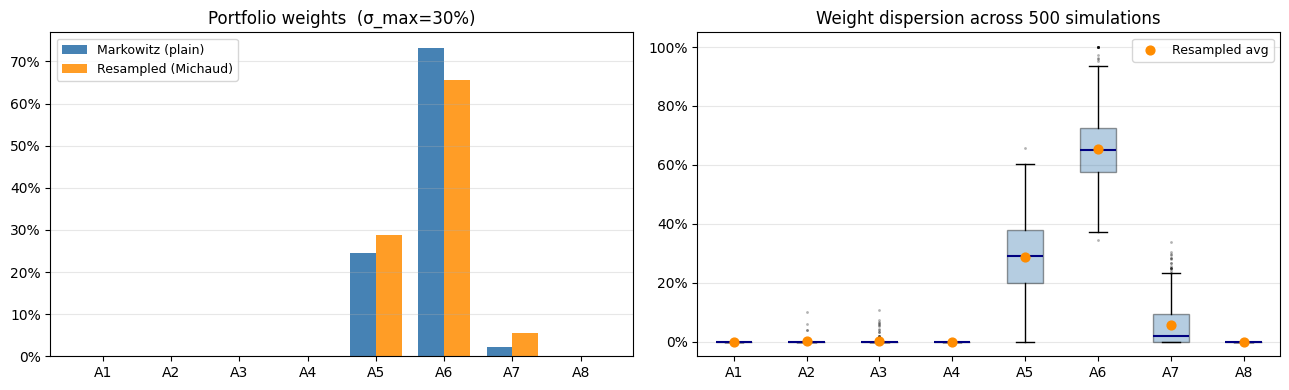

In [3]:
# plain Markowitz (no robustness, original inputs)
w_markowitz = max_return_socp(mu_est, cov_matrix, SIGMA_MAX)

# resampled portfolio
w_resampled, all_weights = michaud_resample(
    mu_est, cov_matrix, sigma_max=SIGMA_MAX, T=252, n_sims=500
)

labels = [f"A{i+1}" for i in range(N)]

# --- summary table ---
print(f"{'':>4}  {'Markowitz':>10}  {'Resampled':>10}")
print("-" * 28)
for i, (wm, wr) in enumerate(zip(w_markowitz, w_resampled)):
    print(f"A{i+1:>2}  {wm:>10.4f}  {wr:>10.4f}")
print()
print(f"{'μ':>4}  {mu_est @ w_markowitz:>10.4f}  {mu_est @ w_resampled:>10.4f}")
print(f"{'σ':>4}  {np.sqrt(w_markowitz @ cov_matrix @ w_markowitz):>10.4f}"
      f"  {np.sqrt(w_resampled @ cov_matrix @ w_resampled):>10.4f}")

# --- plots ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# left: weight comparison
ax = axes[0]
x = np.arange(N)
bw = 0.38
ax.bar(x - bw/2, w_markowitz, bw, label="Markowitz (plain)", color="steelblue")
ax.bar(x + bw/2, w_resampled, bw, label="Resampled (Michaud)", color="darkorange", alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_title(f"Portfolio weights  (σ_max={SIGMA_MAX:.0%})")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis="y")

# right: weight dispersion across simulations (shows why averaging helps)
ax = axes[1]
ax.boxplot(all_weights, labels=labels, patch_artist=True,
           boxprops=dict(facecolor="steelblue", alpha=0.4),
           medianprops=dict(color="navy", lw=1.5),
           flierprops=dict(marker=".", markersize=2, alpha=0.3))
for i, wr in enumerate(w_resampled):
    ax.scatter(i + 1, wr, color="darkorange", zorder=5, s=40,
               label="Resampled avg" if i == 0 else "")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_title("Weight dispersion across 500 simulations")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

The honest tradeoffs: robust optimization is **principled and cheap** (one solve, a clean uncertainty parameter, a worst-case guarantee) but requires you to *specify* the uncertainty set, which can feel arbitrary. Resampling is **intuitive and assumption-light** (just simulate and average) but is **computationally heavy** (thousands of optimizations), has **no theoretical guarantee** (it's a heuristic that empirically smooths), and is **not reproducible** without fixing the random seed — the same reproducibility issue as PSO. It also has subtle statistical criticisms (the averaged portfolio isn't itself optimal for any single coherent objective, and it can retain a long-only bias from averaging).

**Where each fits in practice.** Robust optimization has largely won in production because it's fast, deterministic, and composes with other cone constraints (it stays an SOCP alongside your risk cap, tracking-error limit, etc.). Resampling persists in some asset-management shops (it's Michaud's commercial product) and is pedagogically valuable because it makes the estimation-error problem *visceral* — you literally watch the weights jump around across resamples, which is the most direct way to *see* why raw Markowitz is fragile.